In [19]:
import torch
import torchvision.transforms as transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os
import urllib.request
from PIL import Image

In [20]:
########################################################################################################################
# KREIRANJE MODELA PRETRENIRANOG NA IMAGENET SKUPU
########################################################################################################################

# Učitavamo predefinisane težine i model
weights = EfficientNet_B2_Weights.IMAGENET1K_V1
model = efficientnet_b2(weights=weights)
model.eval() # Postavljamo model u mod za evaluaciju

# U PyTorch-u, pretprocesiranje se najbolje vrši pomoću transformacija vezanih za same težine
preprocess = weights.transforms()

File already exists at /content/elephant.jpg. Skipping download.
Loaded image shape: (1440, 1440, 3)


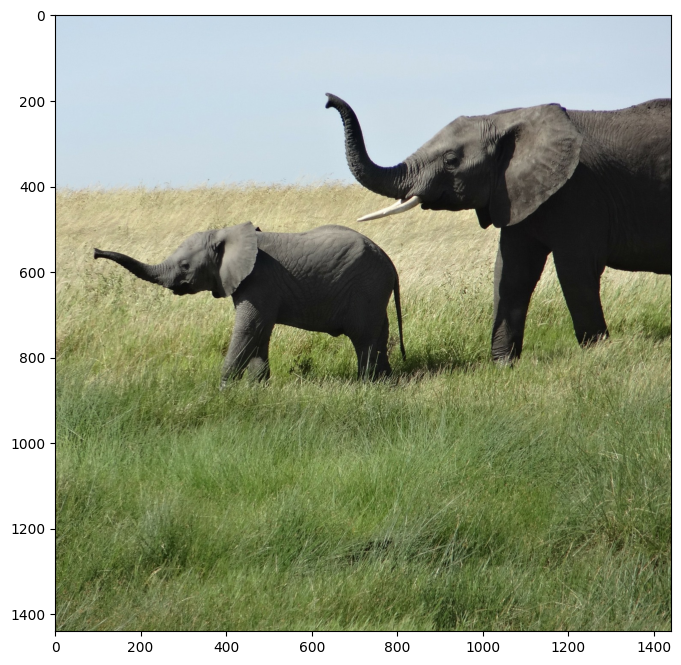

x.shape: torch.Size([1, 3, 288, 288])


In [21]:
########################################################################################################################
# SKIDANJE, UČITAVANJE I PRETPROCESIRANJE SLIKE
########################################################################################################################

# Download image
url = 'https://img-datasets.s3.amazonaws.com/elephant.jpg'
img_path = os.path.join(os.getcwd(), 'elephant.jpg')
if os.path.exists(img_path):
    print(f"File already exists at {img_path}. Skipping download.")
else:
    try:
        urllib.request.urlretrieve(url, img_path)
        print("Image downloaded successfully!")
    except Exception as e:
        print(f"An error occurred: {e}")

# Read input image
img = cv.imread(img_path)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
print('Loaded image shape:', img.shape)

# Show image
plt.figure(figsize=(8, 8))
plt.imshow(img_rgb)
plt.show()

# Konverzija NumPy niza u PIL sliku (potrebno za torchvision transformacije)
img_pil = Image.fromarray(img_rgb)

# Pretprocesiranje slike (automatski radi resize, crop, normalizaciju i konverziju u tenzor)
# Dodajemo batch dimenziju pomoću unsqueeze(0) -> (1, C, H, W)
x = preprocess(img_pil).unsqueeze(0)
print('x.shape:', x.shape)

In [22]:
########################################################################################################################
# NALAŽENJE I PRIKAZ PREDIKCIJE MODELA
########################################################################################################################

# Dobijamo predikcije
output = model(x)
probabilities = torch.nn.functional.softmax(output[0], dim=0)

# Izlistavamo top-3 predikcije
top3_prob, top3_catid = torch.topk(probabilities, 3)
categories = weights.meta["categories"]

print('Top-3 predictions:')
for i in range(top3_prob.size(0)):
    print(f"  {categories[top3_catid[i]]}: {top3_prob[i].item():.4f}")

# Klasa sa najvećom verovatnoćom
pred_class = top3_catid[0].item()
print('Predicted class index:', pred_class)

Top-3 predictions:
  African elephant: 0.7712
  tusker: 0.1320
  Indian elephant: 0.0192
Predicted class index: 386


grads.shape: (1408, 9, 9)
pooled_grads.shape: (1408,)
heatmap.shape: (9, 9)


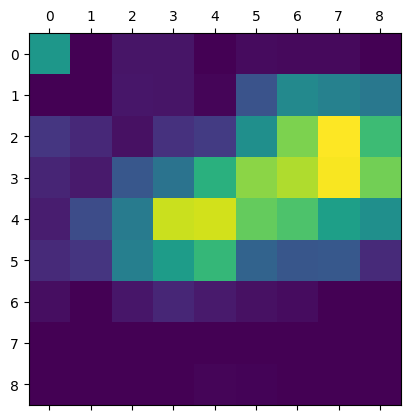

In [23]:
########################################################################################################################
# KREIRANJE HEATMAP-E KORIŠĆENJEM GRAD-CAM METODA
########################################################################################################################

# Inicijalizacija globalnih promenljivih za čuvanje aktivacija i gradijenata
activations = None
gradients = None

# Hook funkcija za čuvanje izlaza (aktivacija) poslednjeg konvolucionog sloja
def forward_hook(module, input, output):
    global activations
    activations = output

# Hook funkcija za čuvanje gradijenata poslednjeg konvolucionog sloja
def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

# U EfficientNet arhitekturi u PyTorch-u, poslednji konvolucioni sloj pre klasifikatora nalazi se u model.features
# model.features[-1] blok je zapravo 'Conv2dNormActivation' koji sadrži Conv2d, BatchNorm i SiLU.
# Conv2d sloju iz tog bloka pristupate sa indeksom 0
last_conv_layer = model.features[-1][0]

# Registracija hook-ova na taj sloj
handle_forward = last_conv_layer.register_forward_hook(forward_hook)
handle_backward = last_conv_layer.register_full_backward_hook(backward_hook)

# Ponovni prolaz unapred
output = model(x)

# Izdvajanje vrednosti koja odgovara prediktovanoj klasi
score = output[0, pred_class]

# Resetujemo gradijente modela
model.zero_grad()

# Računamo gradijente izdvojenog izlaza u odnosu na prethodne slojeve
score.backward()

# Skidamo hook-ove pošto nam više ne trebaju
handle_forward.remove()
handle_backward.remove()

# Prebacujemo aktivacije i gradijente nazad u NumPy
# Izbacujemo batch dimenziju i dobijamo nizove oblika (Channels, Height, Width)
acts = activations.detach().numpy()[0]
grads = gradients.detach().numpy()[0]
print('grads.shape:', grads.shape)

# Računamo srednju vrednost gradijenata po prostornim dimenzijama (H i W, odnosno ose 1 i 2)
pooled_grads = np.mean(grads, axis=(1, 2))
print('pooled_grads.shape:', pooled_grads.shape)

# Množimo vrednosti kanala u aktivacijama sa njihovim težinama (pooled_grads)
for i in range(acts.shape[0]):
    acts[i, :, :] *= pooled_grads[i]

# Srednja vrednost po kanalima (osa 0 u PyTorch-u) predstavlja heatmap-u aktivacija
heatmap = np.mean(acts, axis=0)
print('heatmap.shape:', heatmap.shape)

# ReLU operacija nad heatmap-om (samo pozitivne vrednosti ostaju)
heatmap = np.maximum(heatmap, 0)
# Normalizacija između 0 i 1
heatmap /= np.max(heatmap)

plt.matshow(heatmap)
plt.show()

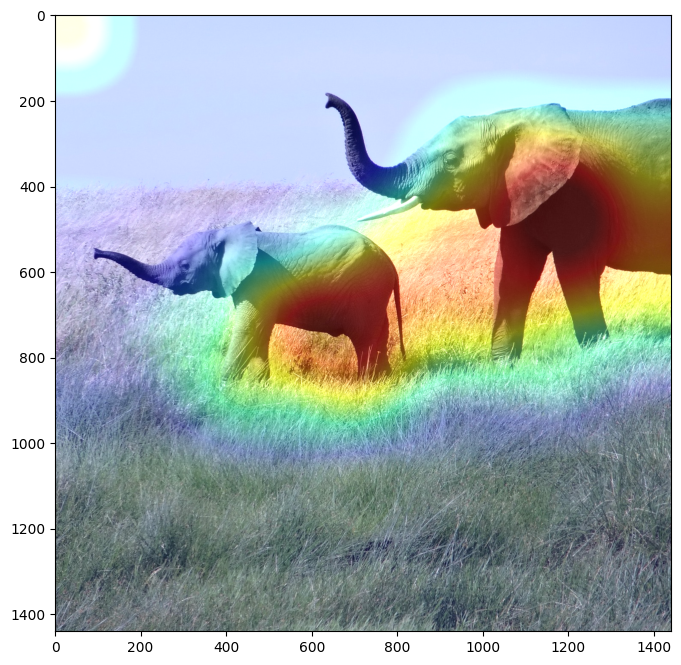

In [24]:
########################################################################################################################
# PRIKAZ HEATMAP-E PREKO ORIGINALNE SLIKE
########################################################################################################################

# Konverzija u grayscale sliku
img_heatmap = np.uint8(255 * heatmap)

# Resize heatmap-e da odgovara originalnoj slici
img_heatmap = cv.resize(img_heatmap, (img.shape[1], img.shape[0]), interpolation=cv.INTER_CUBIC)

# Konverzija heatmap-e u kolornu mapu (JET)
img_heatmap = cv.applyColorMap(img_heatmap, cv.COLORMAP_JET)
img_heatmap = cv.cvtColor(img_heatmap, cv.COLOR_BGR2RGB)

# Spajanje heatmap-e sa originalnom slikom
superimposed_img = np.clip(0.4 * img_heatmap + img_rgb, 0, 255).astype(np.uint8)

# Prikaz rezultata
plt.figure(figsize=(8, 8))
plt.imshow(superimposed_img)
plt.show()